# Winrate side calculation

### Case description
Source data for this calcularion is located where the Data.md file says. No other data has been considered to make this calculation.

The aim of this jupyter notebook is to determine the winrate of each side. Expose the result and ressearch for posible causes. Whether it is based on player skills or there are features that allows to know if one side have and advantage.

| Columna         | Descripción                                                          |
| --------------- | -------------------------------------------------------------------- |
| `side`          | Lado del mapa (`Blue` o `Red`).                                           |
| `teamid`        | Identificador único del equipo.                                           |
| `gamelength`    | Duración de la partida en segundos.                  |
| `result`        | Resultado de la partida (1 = victoria, 0 = derrota). |

### Goals of this learning

# Imports

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import PolynomialFeatures

import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*X does not have valid feature names.*')

# Data read

In [122]:
año = "2024"
df = pd.read_csv(f"../Data/Raw Data/{año}_LoL_esports_match_data_from_OraclesElixir.csv",low_memory=False)

In [123]:
#Each row represents a player match. So for each match there's 10 rows and two more for each team
print("Total of rows:",len(df))
#If it is correct that there is 12 for each match, there should be 122304 / 12 = 10.192
df_match = df.groupby(by="gameid")
total = len(df_match)
print("Total of matches:",total)

#Is it posible to get this statistic by grouping on a team row? As there's two teams, the matches is the half of team lenght.
df_team = df[df["position"] == "team"]
print("Total of rows named as team:",len(df_team)//2)

Total of rows: 122304
Total of matches: 10192
Total of rows named as team: 10192


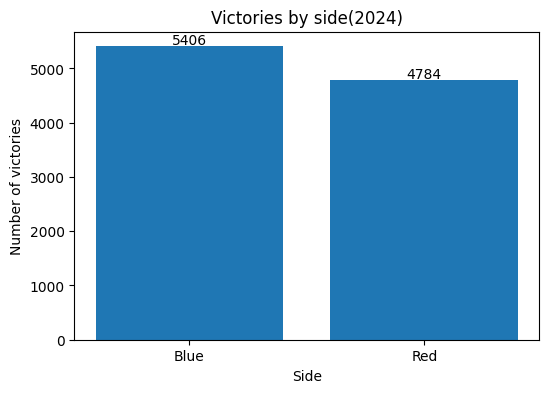

side
Blue    5406
Red     4784
Name: gameid, dtype: int64
Diference: 622
A difference of 6.10%


In [124]:
import matplotlib.pyplot as plt
import math

wins = (
    df_team[df_team["result"] == 1]
    .groupby("side")["gameid"]
    .count()
)

plt.figure(figsize=(6,4))

plt.bar(wins.index, wins.values)

plt.title(f"Victories by side({año})")
plt.xlabel("Side")
plt.ylabel("Number of victories")

for i, v in enumerate(wins.values):
    plt.text(i, v + 30, str(v), ha="center")

plt.show()

print(wins)
diference = abs(wins["Blue"]-wins["Red"])
print("Diference:",diference )
print(f"A difference of {diference/total:.2%}")

# Does this has happened just one year or is a pattern?

In [117]:
iter_wins = []
iter_differences = []

for iter_year in range(2019,2026):
    print("Year:",iter_year)
    iter_df = pd.read_csv(f"../Data/Raw Data/{iter_year}_LoL_esports_match_data_from_OraclesElixir.csv",low_memory=False)
    iter_df_team = iter_df[iter_df["position"] == "team"]
    iter_total = len(iter_df_team) // 2
    iter_wins.append(
        iter_df_team[iter_df_team["result"] == 1]
        .groupby("side")["gameid"]
        .count()
    )
    iter_differences.append(abs(iter_wins[-1]["Blue"]-iter_wins[-1]["Red"]))
    print(iter_wins[-1])
    print("Difference:",iter_differences[-1])
    print(f"A difference of {iter_differences[-1]/iter_total:.2%}")

Year: 2019
side
Blue    4324
Red     3801
Name: gameid, dtype: int64
Difference: 523
A difference of 6.44%
Year: 2020
side
Blue    5136
Red     4611
Name: gameid, dtype: int64
Difference: 525
A difference of 5.39%
Year: 2021
side
Blue    6470
Red     5828
Name: gameid, dtype: int64
Difference: 642
A difference of 5.22%
Year: 2022
side
Blue    6574
Red     5952
Name: gameid, dtype: int64
Difference: 622
A difference of 4.97%
Year: 2023
side
Blue    5920
Red     5185
Name: gameid, dtype: int64
Difference: 735
A difference of 6.62%
Year: 2024
side
Blue    5406
Red     4784
Name: gameid, dtype: int64
Difference: 622
A difference of 6.10%
Year: 2025
side
Blue    5348
Red     4690
Name: gameid, dtype: int64
Difference: 658
A difference of 6.56%


Why this is happening? There's two key years. The 2022 and 2023 are the minimum and the maximum of diference in win rate by side.

In [140]:
#Mean of the gold and experience obtained in the first 10 and 15 minutes of the match
df_team.groupby("side")[["goldat10","xpat10","goldat15","xpat15"]].mean()


,goldat10,xpat10,goldat15,xpat15
side,,,,
Blue,16050.263206,18891.088606,25454.142240,30162.893320
Red,15900.021697,18820.814154,25112.811861,30062.115428


# ¿Cómo demostrarlo con datos?

Aquí es donde puedes convertir un simple gráfico en un análisis estadístico.

1. Contraste de hipótesis

Puedes comprobar si la diferencia es significativa mediante un test binomial o un chi-cuadrado.

Hipótesis:

H₀: Blue gana el 50 % de las partidas.
H₁: Blue gana más del 50 %.

Con más de 10.000 partidas, una diferencia del 53 % probablemente será estadísticamente significativa.

In [63]:
pd.crosstab(df_team["firstPick"],
            df_team["result"],
            normalize="index")

result,0,1
firstPick,,
0.0,0.531414,0.468586
1.0,0.468693,0.531307


In [64]:
df_team.groupby("side")[
    ["firstdragon",
     "firstherald",
     "firsttower",
     "void_grubs"]
].mean()

,firstdragon,firstherald,firsttower,void_grubs
side,,,,
Blue,0.389663,0.609382,0.549709,3.412542
Red,0.609609,0.382781,0.450187,2.109089


5. Modelo predictivo

Una forma muy sólida de demostrar el efecto consiste en ajustar una regresión logística:

Victoria∼Lado+FirstPick+Golddiff
15
	​

+FirstDragon+FirstTower+…

Si el coeficiente asociado a side sigue siendo significativo después de controlar por estas variables, podrás afirmar que el lado tiene un efecto propio sobre la probabilidad de victoria.